In [2]:
import rasterio
from rasterio.plot import show
from rasterstats import zonal_stats
import osmnx as ox
import geopandas as gpd
import pandas as pd
import os
import numpy as np

In [5]:
field_shp = r"D:\imWEBs\STC\STC-Landuse-Data\field\unit_management.shp"
raster_path = r"D:\imWEBs\STC\STC-Landuse-Data\All Years\raster"
output_path = r"D:\imWEBs\STC\STC-Landuse-Data\Processed"
first_year = 1991

#load lookup tables
lookup_path = r"D:\imWEBs\STC\STC-Landuse-Data\Processed\lookups"
year_lookup = "year-lookup.csv"
crop_management_lookup = "crop-management.csv"
fer_management_lookup = "fertilizer-management.csv"
til_management_lookup = "tillage-management.csv"
graz_management_lookup = "grazing-management.csv"
field_subbasin_lookup = "field_subbasin.csv"
flag_not_proceed = "Not proceed"
col_original_crop_id = "Original ID"
col_imwebs_crop_id = "IMWEBs ID"
col_crop_code = "CropCode"
scenario = 1

In [3]:
def get_field_dominant_crop(field_shp, crop_raster):
    """
    get dominant crop for each field

    Parameters
    ----------
    field_shp : the file path of field shapefile
    crop_raster : the file path of crop raster 

    Returns
    -------
    DataFramw with two columns:
    1. Location - Field ID
    2. Original ID - Original Crop Code
    
    """
    stats = zonal_stats(field_shp, crop_raster, band=1,stats='majority count', geojson_out = True)

    field_dominont_crop = {}
    for land in stats:
        #skip if majority is none
        if land['properties']['LAND_ID'] is None or land['properties']['majority'] is None:
            continue
        else:
            field_dominont_crop[int(land['properties']['LAND_ID'])] = int(land['properties']['majority'])
    
    #create dataframe and save the original crop id to Original ID column
    df = pd.DataFrame.from_dict(field_dominont_crop, orient = 'index', columns = [col_original_crop_id])
    df.index.name = 'Location'
    df = df.sort_index()
    df = df.reset_index()

    return df

def add_year(df, current_year, first_year):
    """
    Add year columns

    Parameters
    ----------
    df: data frame
    current_year: the real year
    first_year: the first year of simulation to calcualte the year sequence
    
    """
    df['ActualYear'] = current_year
    df['Year'] = current_year - first_year + 1

    return df


def to_imwebs_crop_code(df_original_crop, year):
    """
    convert the original crop id to imwebs crop id with lookup table
    
    """

    #get name of the crop lookup csv file
    df_year_lookup = pd.read_csv(os.path.join(lookup_path, year_lookup), index_col = 0)
    crop_code_lookup = df_year_lookup.Lookup[year]

    #read crop lookup csv file and dicard not proccessed codes
    df_crop_code_lookup = pd.read_csv(os.path.join(lookup_path,crop_code_lookup + '.csv'), index_col = 0)
    df_crop_code_lookup = df_crop_code_lookup[df_crop_code_lookup[col_imwebs_crop_id]!= flag_not_proceed]
    df_crop_code_lookup[col_imwebs_crop_id] = df_crop_code_lookup[col_imwebs_crop_id].astype(int)

    #join original id and imweb code
    df_field_crop_imwebs = df_original_crop.merge(df_crop_code_lookup, how = 'inner', on = col_original_crop_id)
    df_field_crop_imwebs[col_crop_code] = df_field_crop_imwebs[col_imwebs_crop_id]

    return df_field_crop_imwebs

In [14]:
#add dominant crop id to field shapefile using 1991 crop data
y = 1991

print(f"year: {y}")
crop_raster = os.path.join(raster_path, f'{y}.tif')
df = get_field_dominant_crop(field_shp, crop_raster)
df = to_imwebs_crop_code(df, y)
df = df.rename(columns={"Location":"LAND_ID"})

#add to field and save to specified output file
field_shp_df = gpd.read_file(field_shp)
field_shp_df = field_shp_df.merge(df, on = "LAND_ID", how = "left")
field_shp_df.to_file(r"D:\git\imWEBs\IMWEBsInterface\resources\DemoDatasets\STC2021\landuse_1991.shp")
print("done")


year: 1991
done


C:\Users\hawkl\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:13: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  del sys.path[0]


In [ ]:
#for crop management
years = np.arange(first_year, 2021, 1)

field_crops = []
for y in years:   
    print(f"year: {y}")
    crop_raster = os.path.join(raster_path, f'{y}.tif')

    df = get_field_dominant_crop(field_shp, crop_raster)
    df = add_year(df, y, first_year)
    df = to_imwebs_crop_code(df, y)
    
    field_crops.append(df)
    
df_field_crop = pd.concat(field_crops,ignore_index=True)

df_field_crop.to_csv(os.path.join(output_path, 'dominant_crop.csv'))

#add scenario column
df_field_crop['Scenario'] = scenario


In [13]:
df_field_crop.to_csv(os.path.join(output_path, 'dominant_crop.csv'))

In [15]:
#create random date between first and last day
import random

col_planting_date = ('PlantingMon', 'PlantingDay')
col_harvest_date = ('HarvestMon', 'HarvestDay')
col_fertilizer_date = ('FerMon', 'FerDay')
col_tillage_date = ('TillMon', 'TillDay')
value_use_planting_date = -1
value_30_after_harvest = -30


#create random date with given first month, day and last month and day
def create_random_date(mon_first, day_first, mon_last, day_last):
    #create random planting month and day
    first_day = pd.Timestamp(year = 2000, month = mon_first, day = day_first)
    last_day = pd.Timestamp(year = 2000, month = mon_last, day = day_last)
    day_range = last_day - first_day
    ran = random.randint(0, day_range.days)
    ran_day = first_day + pd.Timedelta(f'{ran} days')
    return (ran_day.month, ran_day.day)

def offset_days(mon, day, offset_days):
    d = pd.Timestamp(year = 2000, month = mon, day = day)
    d = d + pd.Timedelta(f'{offset_days} days')
    
    return (d.month, d.day)

#populate the random date for given index and mon/day column
def populate_random_date(df, index, col_mon, col_day):
    mon_first = df.loc[index, f'{col_mon}_First']
    day_first = df.loc[index, f'{col_day}_First']
    mon_last = df.loc[index, f'{col_mon}_Last']
    day_last = df.loc[index, f'{col_day}_Last']
       
    
    #if one of the mon/day is -1, then planting month/day will be used
    if mon_first == value_use_planting_date | day_first == value_use_planting_date | mon_last == value_use_planting_date | day_last == value_use_planting_date: 
        df.loc[index, col_mon] = df.loc[index, col_planting_date[0]]
        df.loc[index, col_day] = df.loc[index, col_planting_date[1]]
    #if one of the mon/day is -30, then use 30 days after harvest date
    elif mon_first == value_30_after_harvest | day_first == value_30_after_harvest| mon_last == value_30_after_harvest | day_last == value_30_after_harvest: 
        offset = offset_days(df.loc[index, col_harvest_date[0]], df.loc[index, col_harvest_date[1]], 30)
        df.loc[index, col_mon] = offset[0]
        df.loc[index, col_day] = offset[1]        
    else:    
        ran = create_random_date(mon_first, day_first, mon_last, day_last)    
        df.loc[index, col_mon] = ran[0]
        df.loc[index, col_day] = ran[1]

#-------------------------------------------------------------------------------------------------
#crop management
df_crop_management_lookup = pd.read_csv(os.path.join(lookup_path, crop_management_lookup))
df_crop = df_field_crop.merge(df_crop_management_lookup, how = 'inner', on = col_crop_code)

#add planting and harvest month and day column
for col in col_planting_date + col_harvest_date:
    df_crop[col] = -1
    
#add ID column
df_crop['ID'] = df_crop['Location']

#populate the columns
for index in df_crop.index:    
    #planting dates
    populate_random_date(df_crop, index, col_planting_date[0], col_planting_date[1])
    
    #harvest dates
    populate_random_date(df_crop, index, col_harvest_date[0], col_harvest_date[1])

#Get the year. If previous year flag is 1, then previous year is used.
df_crop['Year'] = np.where(df_crop['Pervious Year'] == 1, df_crop['Year'] - 1, df_crop['Year'])

#if the year is zero, then it's winter wheat and we will use year 1 and set plant day to Jan 1st
df_crop[col_planting_date[0]] = np.where(df_crop['Year'] == 0, 1, df_crop[col_planting_date[0]])
df_crop[col_planting_date[1]] = np.where(df_crop['Year'] == 0, 1, df_crop[col_planting_date[1]])
df_crop['Year'] = np.where(df_crop['Year'] == 0, 1, df_crop['Year'])
    
#save crop managment
df_crop.to_csv(os.path.join(output_path, 'crop_management.csv'), index = False, columns = ['Location','Scenario','ID','ActualYear','CropCode',
                                                                                           'Year','PlantingDay','PlantingMon','HarvestDay','HarvestMon',
                                                                                           'HarvestEfficiency','HarvestType','HarvestIndexOverride','CNOP',
                                                                                           'StoverFraction','IsGrain','PRCOP'])

#-------------------------------------------------------------------------------------------------
#fertilizer management
df_fer_management_lookup = pd.read_csv(os.path.join(lookup_path, fer_management_lookup))
df_fertilizer = df_crop.merge(df_fer_management_lookup, how = 'inner', on = col_crop_code)

#add the columns
for col in col_fertilizer_date:
    df_fertilizer[col] = -1

#populate the columns
for index in df_fertilizer.index:    
    #fertilizer dates
    populate_random_date(df_fertilizer, index, col_fertilizer_date[0], col_fertilizer_date[1])
    
#save fertilizer managment
df_fertilizer.to_csv(os.path.join(output_path, 'fertilizer_management.csv'), index = False, columns = ['Scenario','Location','Year','FerMon','FerDay',
                                                                                                       'FerType','FerRate','FerSurface'])
    
    
#-------------------------------------------------------------------------------------------------
#tillage management   
df_til_management_lookup = pd.read_csv(os.path.join(lookup_path, til_management_lookup))
df_tillage = df_crop.merge(df_til_management_lookup, how = 'inner', on = col_crop_code)
    
#add the columns
for col in col_tillage_date:
    df_tillage[col] = -1
        
#populate the columns
for index in df_tillage.index:
    #tillage dates
    populate_random_date(df_tillage, index, col_tillage_date[0], col_tillage_date[1])
    
#save tillage managment
df_tillage.to_csv(os.path.join(output_path, 'tillage_management.csv'), index = False, columns = ['Scenario','Location','Year','TillMon','TillDay','TillCode'])

In [12]:
#-------------------------------------------------------------------------------------------------
#base landuse map
base_landuse_raster = "base_landuse.tif"
base_landuse_lookup = "landuse_lookup.csv"

#get dominate landuse in each field using base landuse map and then repeat for all years
years = np.arange(first_year, 2021, 1)
field_crops = []
for y in years:   
    print(f"year: {y}")
    crop_raster = os.path.join(raster_path, f'{y}.tif')

    df = get_field_dominant_crop(field_shp, crop_raster)
    df = add_year(df, y, first_year)
    df = to_imwebs_crop_code(df, y)
    
    field_crops.append(df)
    
df_field_crop = pd.concat(field_crops,ignore_index=True)
df_field_crop.to_csv(os.path.join(output_path, 'dominant_crop.csv'))


#grazing management
df_grazaing_management_lookup = pd.read_csv(os.path.join(lookup_path, graz_management_lookup))
df_grazing = df_field_crop.merge(df_grazaing_management_lookup, how = 'inner', on = col_crop_code)

df_field_subbasin_lookup = pd.read_csv(os.path.join(lookup_path, field_subbasin_lookup))
df_field_subbasin_lookup = df_field_subbasin_lookup.rename(columns={"Field": "Location", "Subbasin": "SourceID"})
df_grazing = df_grazing.merge(df_field_subbasin_lookup, how = 'inner', on = 'Location')

#save grazing managment
df_grazing.to_csv(os.path.join(output_path, 'grazing_management.csv'), index = False, columns = ['Scenario','Location','Year','GraMon','GraDay','Days',
'Ani_ID','Ani_adult','GR_Density','DayFra','Source', 'SourceID','Dugout_ID','Access','Fencing','StreamAniPerc', 'Drinking_time','BankK_Change'])

In [188]:
df_crop_management_lookup.dtypes

CropCode                  int64
Pervious Year             int64
PlantingMon_First         int64
PlantingDay_First         int64
PlantingMon_Last          int64
PlantingDay_Last          int64
HarvestMon_First          int64
HarvestDay_First          int64
HarvestMon_Last           int64
HarvestDay_Last           int64
HarvestEfficiency       float64
HarvestType               int64
HarvestIndexOverride      int64
CNOP                      int64
StoverFraction            int64
IsGrain                   int64
PRCOP                     int64
dtype: object

In [186]:
df_crop.dtypes

Location                  int64
Original ID               int64
Year                      int32
Land use name            object
Group                    object
IMWEBs code              object
IMWEBs ID                 int32
CropCode                  int32
Pervious Year           float64
PlantingMon_First       float64
PlantingDay_First       float64
PlantingMon_Last        float64
PlantingDay_Last        float64
HarvestMon_First        float64
HarvestDay_First        float64
HarvestMon_Last         float64
HarvestDay_Last         float64
HarvestEfficiency       float64
HarvestType             float64
HarvestIndexOverride    float64
CNOP                    float64
StoverFraction          float64
IsGrain                 float64
PRCOP                   float64
PlantingMon               int64
PlantingDay               int64
HarvestMon                int64
HarvestDay                int64
dtype: object

In [193]:
df_crop.to_csv(r"D:\imWEBs\STC\STC-Landuse-Data\Processed\crop_management.csv")

In [ ]:
#merge 
df_final = df_field_crop.merge(df_crop_code_lookup, how = 'left', on = 'Original ID')

In [ ]:
#create structure for crop management, fertilizer management and tillage management
df_crop_management_cols = ['Location', 'Scenario', 'ID', 'ActalYear',
                           'CropCode','Year','PlantingDay','PlantingMon',
                          'HavestDay', 'HarvestMon','HarvestEfficiency',
                          'HavestType', 'HavestIndexOveride', 'CNOP', 
                          'StoverFraction', 'IsGrain', 'PRCOP']
df_crop_management = pd.DataFrame(columns = [])

In [38]:
dem = rasterio.open(dem_fp)

In [9]:
dem

<open DatasetReader name='D:/imWEBs/STC/STC-Landuse-Data/AAFC_Crop_Inventory_MB/clipped/2020.tif' mode='r'>

In [28]:
shp = gpd.read_file(boundary_shp)
shp
json = shp.to_json()

In [31]:
with open(r"D:\imWEBs\STC\STC-Landuse-Data\Processed\ZonalStatistics\2020.geojson",'w',encoding = 'utf-8') as f:
   f.write(json)

In [33]:
shp2 = gpd.read_file(r"D:\imWEBs\STC\STC-Landuse-Data\Processed\ZonalStatistics\2020.geojson")
shp2


,id,ACRES,LAND_ID,PRODUCER_N,SHAPE_AREA,SHAPE_LENG,YEAR,geometry
0,0,3.578817,700,NaN,1.448296e+04,532.529679,NaN,"POLYGON ((542972.126 5473618.000, 542981.001 5..."
1,1,492.859181,21,102.0,1.994530e+06,6126.866898,2005.0,"POLYGON ((542972.126 5473618.000, 543059.876 5..."
2,2,31.170025,1,9.0,1.261406e+05,1686.980592,2005.0,"POLYGON ((542918.312 5472838.000, 542873.812 5..."
3,3,22.067148,2,16.0,8.930258e+04,1719.413204,2005.0,"POLYGON ((542918.312 5472838.000, 542918.812 5..."
4,4,0.398083,700,NaN,1.610986e+03,200.985904,NaN,"POLYGON ((542924.376 5472031.000, 542920.001 5..."
...,...,...,...,...,...,...,...,...
984,984,86.319891,352,24.0,3.493242e+05,3081.651346,2005.0,"POLYGON ((544534.376 5467983.000, 544535.438 5..."
985,985,54.478040,157,49.0,2.204648e+05,2860.383726,2005.0,"POLYGON ((544563.812 5464799.000, 544558.312 5..."
986,986,52.109869,353,49.0,2.108812e+05,5179.637373,2005.0,"POLYGON ((546015.126 5463699.500, 546018.312 5..."
987,987,1.097818,600,NaN,4.442711e+03,295.453461,NaN,"POLYGON ((545395.812 5463384.000, 545398.856 5..."


<AxesSubplot:>

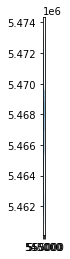

In [34]:
shp2.plot()

<AxesSubplot:>

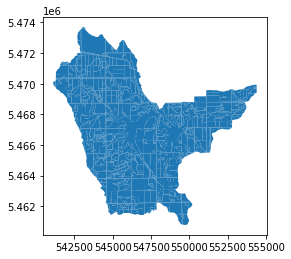

In [27]:
shp.plot()

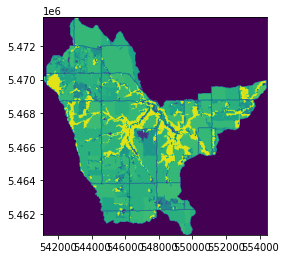

<AxesSubplot:>

<Figure size 432x288 with 0 Axes>

In [10]:
ax = show((dem, 1))
shp.plot(ax=ax, facecolor='None', edgecolor='red', linewidth=2)

In [27]:
array = dem.read(1)

In [26]:
array

array([[220, 220, 230, ...,   0,   0,   0],
       [230,  80,  80, ...,   0,   0,   0],
       [230, 230, 210, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8)

In [ ]:
zonal_stats(kallio, array, affine=affine, stats=['min', 'max', 'mean', 'median', 'majority'])